Martí Puig i Sebastián Luna Competició AA1

Importació de Llibreries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

# Set the precision of the display to 3 decimal places
pd.set_option('display.precision', 3)

Anàlisi Exploratori de les Dades (AED)

In [2]:
csi = pd.read_csv("train_nt.csv",header=0,delimiter=";")
csi_final_test = pd.read_csv("test_nolabels_nt.csv",header=0,delimiter=";") #es el dataset on intentarem predir els labels pel Kaggle

In [3]:
csi.columns #noms dels atributs, recordem que ID NO es una feature, aixi que la treurem fora

Index(['ID', 'seq_ctrl', 'aoa', 'rssi1', 'rssi2', 'I0_1', 'Q0_1', 'I1_1',
       'Q1_1', 'I2_1',
       ...
       'Q59_2', 'I60_2', 'Q60_2', 'I61_2', 'Q61_2', 'I62_2', 'Q62_2', 'I63_2',
       'Q63_2', 'position'],
      dtype='object', length=262)

In [6]:
csi = csi.drop(columns="ID")
csi

,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,Q2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
0,0,-5703,-88,-88,0,0,4,5,7,8,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,0,1835,-91,-88,0,0,-10,4,-7,3,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,0,4,-86,-87,0,0,5,14,5,5,...,10,7,16,7,13,11,16,11,13,9
3,52464,1259,-81,-71,0,0,-1,12,1,11,...,13,-7,14,-6,17,-6,16,-7,16,2
4,0,900,-82,-76,0,0,9,2,9,-3,...,6,14,4,16,7,14,7,14,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12883,0,3976,-84,-88,0,0,-5,-17,-9,-17,...,-5,11,-4,0,8,13,-5,9,-3,6
12884,38112,1388,-80,-87,0,0,4,9,1,6,...,14,-1,12,2,13,-6,13,-3,8,2
12885,0,957,-65,-69,0,0,-13,9,-16,9,...,-2,-17,-2,-17,-1,-17,-2,-17,-1,3
12886,26416,-127,-71,-69,0,0,16,2,14,0,...,-8,13,-9,13,-9,15,-10,14,-10,3


Explicació de les Variables:
- `seq_ctrl`: uint16 seqüència de nombres per identificar el csi. 
- `aoa`: float32, attribut  sintétic generat al post-processament, representa l'angle estimat d'arribada (azimuth, en radians) calculat desde la fase de diférencia entre 2 antenas receptoras
- `rssi1`: int8, indicador de l'intensitat del senyal mesurat rebuda per la primera antena. 
- `rssi2`: int8, indicador de l'intensitat del senyal mesurat rebuda per la segona antena.  
- Dades Raw CSI en forma de 64 nombres complexos, primer per la antena 1, segon per la antena 2, de la forma següent:

I0_1 Q0_1 I1_1 Q1_1 ... I63_1 Q63_1

I0_2 Q0_2 ... I63_2 Q63_2 

on In_X: Valor In-phase del subcarrier n-èssim $(0 \leq n \leq 63)$ a la antena X (X = 1 o 2) 
i Qn_X: Valor Quadraturedel subcarrier n-èssim a la antena X
- `position` (label): int8, valor entre 0 i 9, corresponent a la posició del target device (Variable Target)

In [8]:
csi_shape = csi.shape
print(f"El dataset té {csi_shape[0]} mostres i {csi_shape[1]} attributs")

El dataset té 12888 mostres i 261 attributs


In [7]:
csi.describe()

,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,Q2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
count,12888.000,12888.000,12888.000,12888.000,12888.0,12888.0,12888.000,12888.000,12888.000,12888.000,...,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000
mean,16008.410,15.017,-78.052,-77.952,0.0,0.0,-0.406,-0.478,-0.500,-0.513,...,-0.402,-0.355,-0.296,-0.328,-0.295,-0.311,-0.269,-0.241,-0.363,4.493
std,19829.509,3087.311,6.805,8.349,0.0,0.0,10.209,10.123,10.416,10.474,...,10.549,10.407,10.520,11.013,11.160,11.075,11.248,11.018,11.118,2.871
min,0.000,-8703.000,-97.000,-94.000,0.0,0.0,-25.000,-26.000,-24.000,-26.000,...,-25.000,-25.000,-26.000,-32.000,-38.000,-25.000,-26.000,-27.000,-31.000,0.000
25%,0.000,-1751.000,-83.000,-84.000,0.0,0.0,-10.000,-10.000,-10.000,-10.000,...,-10.000,-10.000,-10.000,-10.000,-10.000,-11.000,-11.000,-10.000,-11.000,2.000
50%,5464.000,-30.000,-80.000,-80.000,0.0,0.0,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000
75%,29424.000,1798.000,-74.000,-71.000,0.0,0.0,9.000,9.000,9.000,9.000,...,9.000,9.000,9.000,10.000,10.000,10.000,10.000,10.000,10.000,7.000
max,65520.000,8915.000,-58.000,-58.000,0.0,0.0,25.000,25.000,23.000,22.000,...,23.000,29.000,23.000,33.000,35.000,25.000,25.000,26.000,26.000,9.000


In [ ]:
csi['seq_ctrl'].value_counts() #veiem que hi han sequencies que es repeteixen

seq_ctrl
0        5501
51200      32
13440      24
53520      22
43536      21
         ... 
11968       1
50880       1
5744        1
36416       1
14384       1
Name: count, Length: 2788, dtype: int64

In [15]:
csi['position'].value_counts() #el nombre de mostres a cada posicio es similar

position
1    1488
5    1397
8    1312
7    1278
9    1273
4    1249
3    1237
6    1230
2    1224
0    1200
Name: count, dtype: int64

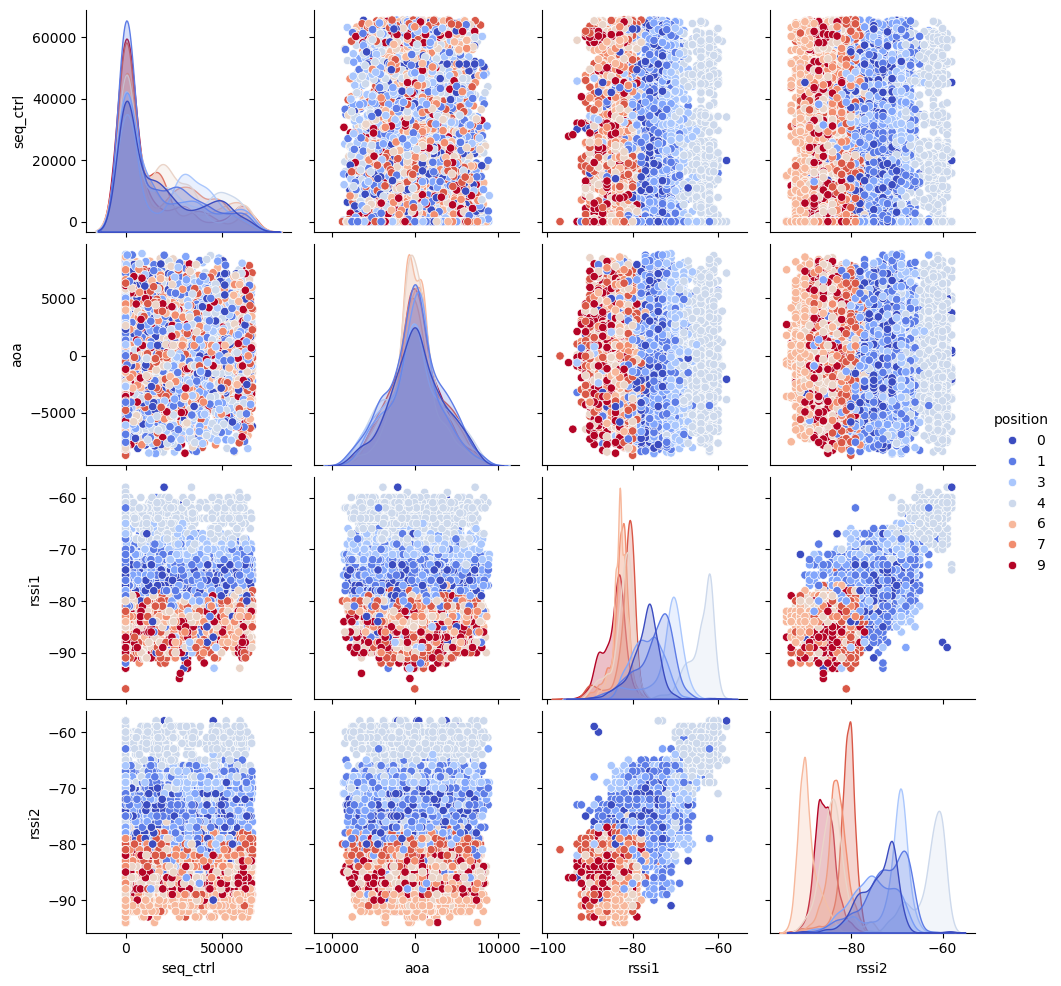

In [ ]:
sn.pairplot(data=csi[["seq_ctrl","aoa","rssi1","rssi2","position"]], hue='position',palette="coolwarm") #no seleccionem ara les RAW CSI variables

In [ ]:
csi_train, csi_test = train_test_split(csi, test_size=0.25, random_state=42, stratify=csi['position']) #stratify fara que es conservin les mateixes proporcions de la feature position

Dataset Cleaning
- Eliminar Outliers
- Escalar Dades
- Reduir Variables
- Balancejar Dataset (si no ho está)

1.LDA

2.QDA

3.Naive-Bayes Classifier

4.Neural Probabilistic Classifier

5.K-NN

6.Logistic Regression

7.SVM

8.Mirar més métodes a la resta de transpas